# Alignment of ORF sequences to cDNA sequences using minimap2

## Create an index for minimap2


In [ ]:
%%bash

minimap2 -x map-ont -d "/media/niek/4TB_SSD2/analyses/GPS_ONT/gencode_transcriptome.mmi" gencode.v49.pc_transcripts.fa.gz

[M::mm_idx_gen::14.165*1.57] collected minimizers
[M::mm_idx_gen::17.142*1.81] sorted minimizers
[M::main::18.972*1.74] loaded/built the index for 245535 target sequence(s)
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 245535
[M::mm_idx_stat::19.201*1.73] distinct minimizers: 14406706 (26.60% are singletons); average occurrences: 8.272; average spacing: 5.382; total length: 641403928
[M::main] Version: 2.30-r1287
[M::main] CMD: minimap2 -x map-ont -d /media/niek/4TB_SSD2/analyses/GPS_ONT/gencode_transcriptome.mmi gencode.v49.pc_transcripts.fa.gz
[M::main] Real time: 19.350 sec; CPU: 33.319 sec; Peak RSS: 3.668 GB


## Align the ORF sequences to the cDNA sequences using minimap2

Alignn with Minimap2, convert to BAM format and sort by RNAME (i.e. mapped reference sequence, cDNA):

In [14]:
%%bash

REF="/media/niek/4TB_SSD2/analyses/GPS_ONT/gencode_transcriptome.mmi"
READS="/media/niek/4TB_SSD2/analyses/GPS_ONT/orfs_barcode_description.fastq.gz"
OUTPUT_BAM="/media/niek/4TB_SSD2/analyses/GPS_ONT/orfs_aligned.bam"

# Only keep primary alignments (i.e. best hit) and sort the output BAM file.
# The -y flag will move the BC:Z: tag to the read name.
# The --eqx flag will use extended CIGAR strings with = and X for matches and mismatches.
minimap2 -ax map-ont --eqx -y -t 8 --secondary=no $REF $READS | \
    samtools view -u - | \
    samtools sort -@ 4 -o $OUTPUT_BAM

[M::main::2.039*0.93] loaded/built the index for 245535 target sequence(s)
[M::mm_mapopt_update::2.415*0.94] mid_occ = 265
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 245535
[M::mm_idx_stat::2.633*0.95] distinct minimizers: 14406706 (26.60% are singletons); average occurrences: 8.272; average spacing: 5.382; total length: 641403928
[M::worker_pipeline::202.384*7.64] mapped 554908 sequences
[M::worker_pipeline::386.654*7.84] mapped 555311 sequences
[M::worker_pipeline::571.739*7.91] mapped 555526 sequences
[M::worker_pipeline::764.850*7.95] mapped 554970 sequences
[M::worker_pipeline::939.448*7.97] mapped 555675 sequences
[M::worker_pipeline::1122.096*7.99] mapped 555508 sequences
[M::worker_pipeline::1303.851*8.00] mapped 553551 sequences
[M::worker_pipeline::1494.299*8.00] mapped 555993 sequences
[M::worker_pipeline::1666.338*8.01] mapped 555593 sequences
[M::worker_pipeline::1849.746*8.02] mapped 555920 sequences
[M::worker_pipeline::2044.084*8.02] mapped 555800 sequen

In [15]:
%%bash

OUTPUT_BAM="/media/niek/4TB_SSD2/analyses/GPS_ONT/orfs_aligned.bam"

samtools view $OUTPUT_BAM | head 

3ba5d9d5-a3e0-411d-ac4b-77962af82eab	0	ENST00000426406.4|ENSG00000284733.2|OTTHUMG00000002860.3|OTTHUMT00000007999.3|OR4F29-201|OR4F29|939|CDS:1-939|	1	0	42=1X206=1X1=4I382=1D304=1S	*	0	0	ATGGATGGAGAGAATCACTCAGTGGTATCTGAGTTTTTGTTTGTGGGACTCACTCATTCATGGGAGATCCAGCTCCTCCTCCTAGTGTTTTCCTCTGTGCTCTATGTGGCAAGCATTACTGGAAACATCCTCATTGTGTTTTCTGTGACCACTGACCCTCACTTACACTCCCCCATGTACTTTCTACTGGCCAGTCTCTCCTTCATTGACTTAGGAGCCTGCTCTGTCACTTCTCCCAAGATGATTTATAACAAGCCTGTTCAGAAAGCGCAAAGTCATCTCCTTTGGAGGCTGCATCGCTCAAATCTTCTTCATCCACGTCGTTGGTGGTGTGGAGATGGTGCTGCTCATAGCCATGGCCTTTGACAGATATGTGGCCCTATGTAAGCCCCTCCACTATCTGACCATTATGAGCCCAAGAATGTGCCTTTCATTTCTGGCTGTTGCCTGGACCCTTGGTGTCAGTCACTCCCTGTTCCAACTGGCATTTCTTGTTAATTTAGCCTTCTGTGGCCCTAATGTGTTGGACAGCTTCTACTGTGACCTTCCTCGGCTTCTCAGACTAGCCTGTACCGACACCTACAGATTGCAGTTCATGGTCACTGTTAACAGTGGGTTTATCTGTGTGGGTACTTTCTCATACTTCTAATCTCCTACGTCTTCATCCTGTTTACTGTTTGGAAACATTCCTCAGGTGGTTCATCCAAGGCCCTTTCCACTCTTTCAGCTCACAGCACAGTGGTCCTTTTGTTCTTTGGTCCACCCATGTTTGTGTATACACGGCCACACCCTAATTCACAGATGGACAAGTT

Barcode sequences have been moved to the description of the ORF reads in the format `BC:Z:{barcode_sequence}`. 

This allows us to easily extract the barcode information from the aligned BAM file using tools like pysam.

## Alignment statistics

Get alignment statistics using samtools flagstat:

In [16]:
%%bash

samtools flagstat /media/niek/4TB_SSD2/analyses/GPS_ONT/orfs_aligned.bam

11735275 + 0 in total (QC-passed reads + QC-failed reads)
11611390 + 0 primary
0 + 0 secondary
123885 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
11246033 + 0 mapped (95.83% : N/A)
11122148 + 0 primary mapped (95.79% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


Very good alignment rates (95.83%), which means most ORF sequences can be mapped to the GenCode cDNA sequences.

## Barcodes per sequenced ORF

Determine how many unique barcodes are associated with each ORF.

Approach:

1. Read the cDNA name sorted BAM file line by line.
2. Skip any reads that are unmapped.
3. Keep reading lines until we encounter a new cDNA name (RNAME).
4. For each cDNA, extract the barcode sequences from the description field (BC) of the aligned reads.
5. Count the total number of barcodes and the number of unique barcodes.
6. Convert the data into a DataFrame with columns: cDNA name, total barcodes, unique barcodes.
7. Save the DataFrame as a CSV file for further analysis and visualization.

In [19]:
%%bash

# Index BAM file 
samtools index -@ 8 /media/niek/4TB_SSD2/analyses/GPS_ONT/orfs_aligned.bam

In [21]:
import pysam
import pandas as pd
from itertools import groupby
from tqdm import tqdm

def process_ont_bam(input_bam, output_csv):
    results = []
    
    # Open the BAM file
    bam = pysam.AlignmentFile(input_bam, "rb")

    # Estimate total iterations for the progress bar
    # Using the index statistics is much faster than counting manually
    total_reads = bam.mapped + bam.unmapped
    
    # Initialize tqdm progress bar
    pbar = tqdm(total=total_reads, desc="Processing Reads", unit="read")

    # Group by Reference Name (RNAME)
    for rname, reads in groupby(bam, key=lambda x: x.reference_name):
        # rname is None for unmapped reads in name-sorted files
        if rname is None:
            # We still need to update the progress bar for these reads
            for read in reads:
                pbar.update(1)
            continue
            
        barcodes = []
        for read in reads:
            pbar.update(1) # Update for every read processed
            
            if read.is_unmapped:
                continue
                
            try:
                bc = read.get_tag("BC")
                if bc:
                    barcodes.append(bc)
            except KeyError:
                continue

        if barcodes:
            results.append({
                "cDNA_name": rname,
                "total_barcodes": len(barcodes),
                "unique_barcodes": len(set(barcodes))
            })

    pbar.close()
    bam.close()

    # Create DataFrame and save
    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)
    print(f"\nDone! Results saved to {output_csv}")
    
process_ont_bam("/media/niek/4TB_SSD2/analyses/GPS_ONT/orfs_aligned.bam", "barcode_counts.csv")

Processing Reads: 100%|██████████| 11735275/11735275 [01:29<00:00, 131329.76read/s]



Done! Results saved to barcode_counts.csv


Now using R, create two histograms: one for the total number of barcodes per cDNA and one for the number of unique barcodes per cDNA.

--------------

```R
library(tidyverse)

# Load CSV file
data <- read_csv("barcode_counts.csv")

# Convert to long format for plotting
data_long <- pivot_longer(
  data,
  cols = c("total_barcodes", "unique_barcodes"),
  names_to = "Status",
  values_to = "Count"
) %>%
  group_by(Status) %>%
  mutate(median_count = median(Count)) %>%
  ungroup() %>%
  # remove barcodes with extremely high counts
  # for better visualization
  filter(ifelse(Status == "unique_barcodes", Count <= 125, Count <= 1000))

# Set the order of the Status for consistent coloring
data_long$Status <- factor(
  data_long$Status,
  levels = c("total_barcodes", "unique_barcodes"),
  labels = c("Total Barcodes", "Unique Barcodes")
)

# Create histogram
p <- ggplot(data_long, aes(x = Count)) +
  geom_histogram(
    aes(fill = Status),
    alpha = 0.7,
    position = "identity",
    bins = 100
  ) +
  facet_wrap(~Status, ncol = 2, scales = 'free') +
  theme_cowplot(12) +
  labs(
    x = "Barcode count",
    y = "Count",
    fill = "Status"
  ) +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none"
  ) +
  scale_fill_manual(
    values = c(
      "Total Barcodes" = "steelblue",
      "Unique Barcodes" = "salmon"
    )
  ) +
  scale_y_continuous(
    expand = c(0, 0.15)
  ) +
  geom_vline(
    aes(xintercept = median_count),
    color = "black",
    linetype = "dashed"
  ) +
  geom_text(
    aes(x = median_count, label = paste0("Median: ", median_count)),
    y = Inf,
    x = 10,
    vjust = 2,
    hjust = -0.1,
    size = 3.5,
  )

# Save plot
ggsave(
  "05_barcode_counts_histogram.png",
  plot = p,
  width = 6,
  height = 4,
  dpi = 300,
  bg = "white"
)

```

--------------
File name: 05_plot_barcode_counts.R


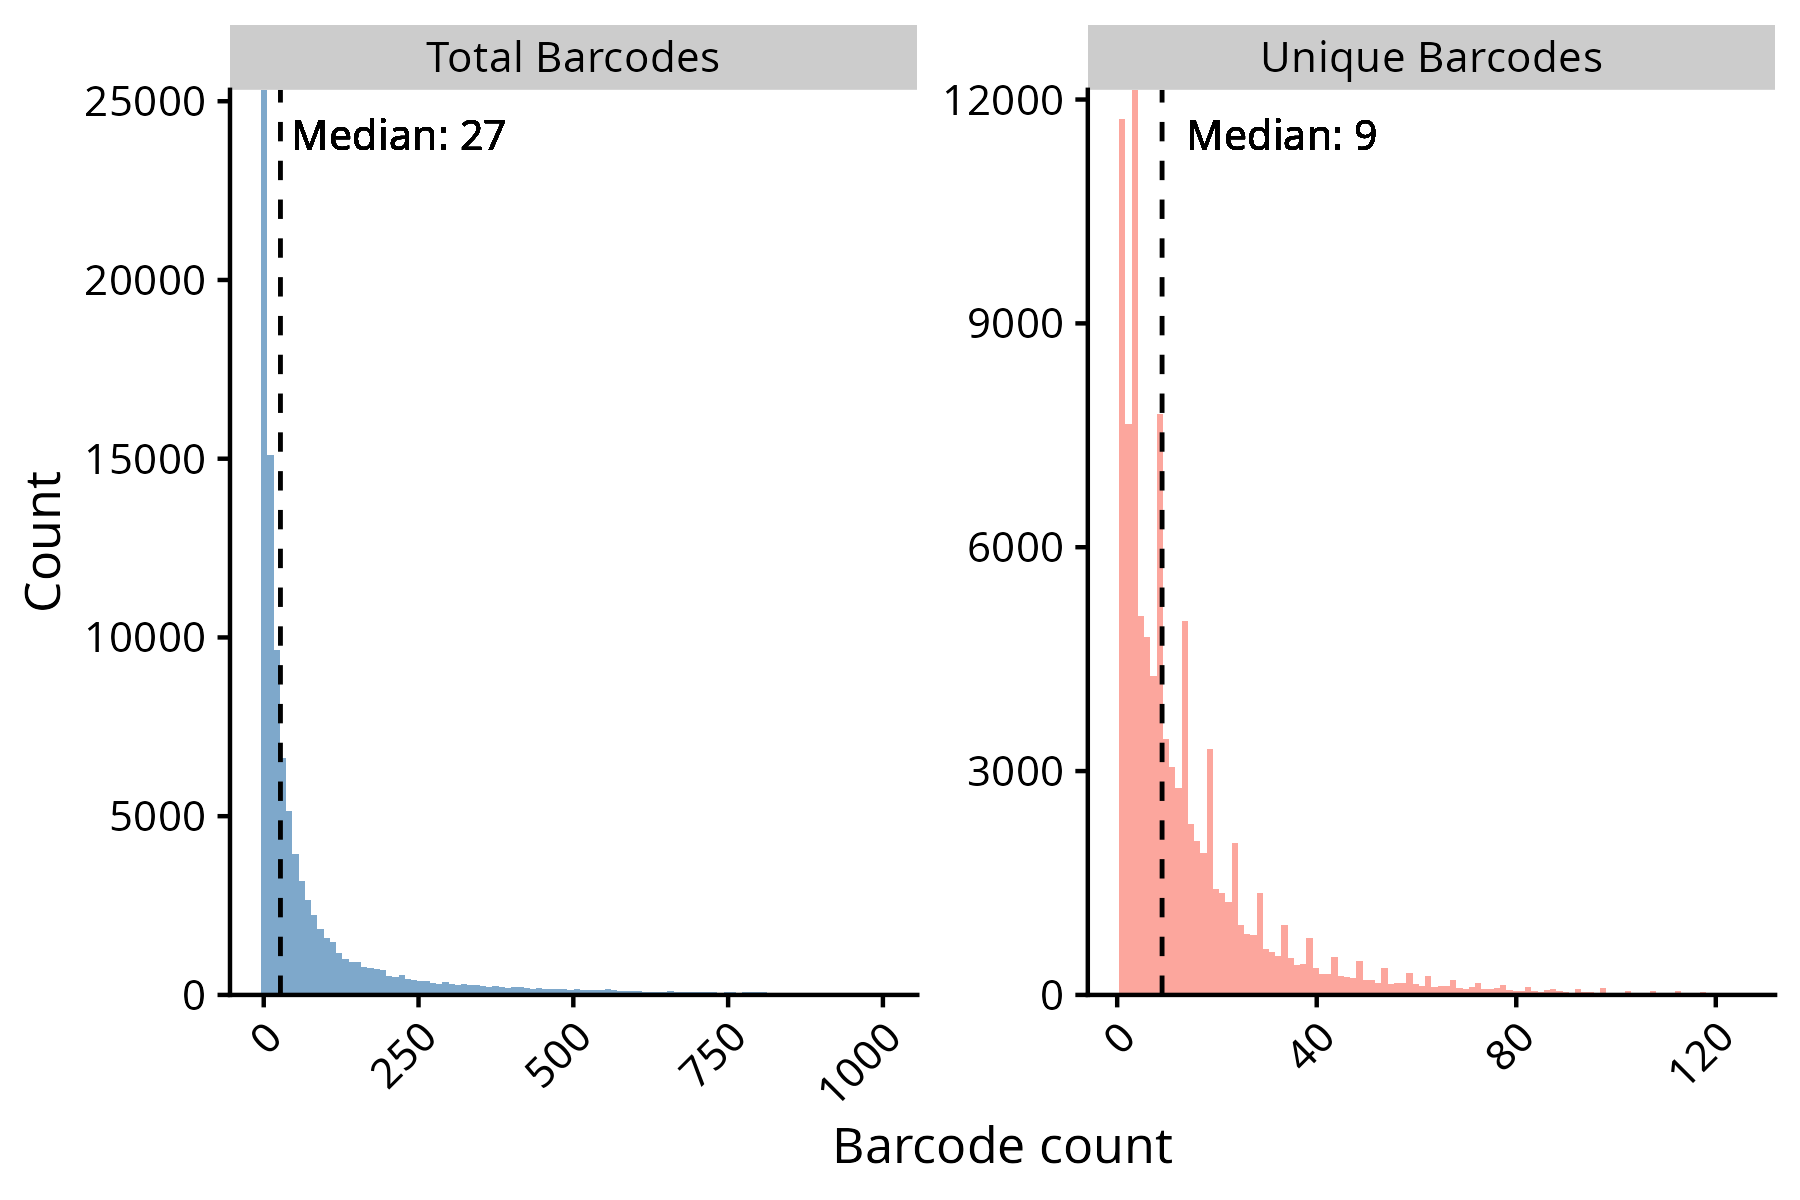

Note: the histograms have been truncated to better visualize the distribution of barcodes per cDNA. Some cDNAs have a very high number of barcodes, which can skew the visualization. By filtering out these extreme values, we can get a clearer picture of the overall distribution of barcodes per cDNA. Data sorted by counts (top 10):

```text
cDNA_name	total_barcodes	unique_barcodes
ENST00000390237.2|ENSG00000211592.8|OTTHUMG00000151684.1|OTTHUMT00000323482.1|IGKC-201|IGKC|523|CDS:1-323|UTR3:324-523|	12852	979
ENST00000390325.2|ENSG00000211679.2|OTTHUMG00000151217.4|OTTHUMT00000321821.4|IGLC3-201|IGLC3|462|CDS:1-320|UTR3:321-462|	9983	735
ENST00000390323.2|ENSG00000211677.2|OTTHUMG00000151214.3|OTTHUMT00000321818.3|IGLC2-201|IGLC2|462|CDS:1-320|UTR3:321-462|	8169	620
ENST00000611116.2|ENSG00000277734.8|OTTHUMG00000028683.8|OTTHUMT00000071613.6|TRAC-201|TRAC|978|CDS:1-425|UTR3:426-978|	6034	509
ENST00000390308.2|ENSG00000211662.2|OTTHUMG00000151213.2|OTTHUMT00000321817.2|IGLV3-21-201|IGLV3-21|602|UTR5:1-251|CDS:252-602|	5132	358
ENST00000297623.7|ENSG00000164972.14|OTTHUMG00000000437.5|OTTHUMT00000001098.4|SPMIP6-201|SPMIP6|1129|UTR5:1-177|CDS:178-966|UTR3:967-1129|	4612	360
ENST00000296215.8|ENSG00000163877.11|OTTHUMG00000004225.4|OTTHUMT00000012169.4|SNIP1-201|SNIP1|4554|UTR5:1-64|CDS:65-1255|UTR3:1256-4554|	4303	405
ENST00000616305.2|ENSG00000274070.2|OTTHUMG00000181541.3|OTTHUMT00000456515.3|CASTOR2-201|CASTOR2|8100|UTR5:1-281|CDS:282-1271|UTR3:1272-8100|	4230	323
ENST00000576892.8|ENSG00000262919.9|OTTHUMG00000024206.8|OTTHUMT00000060992.5|CCNQ-204|CCNQ|1253|UTR5:1-66|CDS:67-813|UTR3:814-1253|	3828	205
ENST00000309324.9|ENSG00000174917.10|OTTHUMG00000180503.2|OTTHUMT00000451656.1|MICOS13-201|MICOS13|516|UTR5:1-30|CDS:31-387|UTR3:388-516|	3654	263

```


**Please note that** one caveat of this analysis is that if a barcode sequence has a sequencing error, it will be counted as a unique barcode, which may inflate the number of unique barcodes per cDNA. 

However, the overall distribution still provides insight into the diversity of barcodes associated with each cDNA.

This can be corrected later?